# Рубежный контроль №1: предобработка данных

**Задача:** масштабирование одного числового признака; преобразование одного категориального признака методами **Label Encoding** и **One-Hot Encoding**; построение **парных диаграмм**.

**Датасет:** [Heart Disease Dataset (Kaggle)](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) — классический набор Cleveland (UCI), 303 наблюдения, 14 признаков. Локальная копия: `heart.csv` (загружена с открытого зеркала, совместимого с Kaggle-версией).


## 1. Описание набора данных

| Признак | Описание |
|---------|----------|
| `Age` | Возраст |
| `Sex` | Пол (1 — муж, 0 — жен) |
| `ChestPain` | Тип боли в груди (категориальный) |
| `RestBP` | Давление в покое |
| `Chol` | Холестерин |
| `Fbs` | Сахар натощак > 120 мг/дл |
| `RestECG` | Результаты ЭКГ в покое |
| `MaxHR` | Макс. ЧСС |
| `ExAng` | Стенокардия при нагрузке |
| `Oldpeak` | Депрессия ST |
| `Slope` | Наклон пика ST |
| `Ca` | Число сосудов (0–3), есть пропуски |
| `Thal` | Таллий-сканирование (категориальный) |
| `AHD` | Наличие болезни сердца (Yes/No) |

Датасет подходит для задания: есть **категориальные** признаки и **пропуски** (`Ca`, `Thal`).


## Импорт библиотек


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

%matplotlib inline
sns.set(style='ticks')


## 2. Загрузка и первичный осмотр


In [ ]:
DATA_PATH = Path('heart.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('rk1/heart.csv')

df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()


Размер: 303 строк, 14 столбцов


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [ ]:
df.info()
print('\nПропуски:')
print(df.isnull().sum()[df.isnull().sum() > 0])


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    str    
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    str    
 13  AHD        303 non-null    str    
dtypes: float64(2), int64(9), str(3)
memory usage: 33.3 KB

Пропуски:
Ca      4
Thal    2
dtype: int64


## 3. Обработка пропусков

В данных есть пропуски в `Ca` и `Thal`. Числовой `Ca` заполним медианой, категориальный `Thal` — модой (наиболее частым значением).


In [ ]:
df_clean = df.copy()

df_clean['Ca'] = df_clean['Ca'].fillna(df_clean['Ca'].median())
df_clean['Thal'] = df_clean['Thal'].fillna(df_clean['Thal'].mode()[0])

assert df_clean.isnull().sum().sum() == 0
print('Пропусков после заполнения:', df_clean.isnull().sum().sum())


Пропусков после заполнения: 0


## 4. Кодирование категориальных признаков

Выбран один признак для каждого метода — **`ChestPain`** (тип боли в груди, 4 категории, **номинальный** — порядок категорий не важен).

### 4.1 Label Encoding — признак `Thal`

**Метод:** `sklearn.preprocessing.LabelEncoder` — каждой категории присваивается целое число 0, 1, 2, …

**Почему `Thal`:** три уровня таллий-сканирования (`fixed`, `normal`, `reversable`). Для демонстрации метода достаточно одного категориального столбца. Label Encoding компактен (один столбец), но **вводит искусственный порядок** между несвязанными категориями — для номинальных признаков это может вводить модель в заблуждение; здесь используем его осознанно для сравнения с One-Hot.


In [ ]:
df_enc = df_clean.copy()

le_thal = LabelEncoder()
df_enc['Thal_le'] = le_thal.fit_transform(df_enc['Thal'])

mapping = dict(zip(le_thal.classes_, le_thal.transform(le_thal.classes_)))
print('Label Encoding Thal:', mapping)
df_enc[['Thal', 'Thal_le']].drop_duplicates().sort_values('Thal_le')


Label Encoding Thal: {'fixed': np.int64(0), 'normal': np.int64(1), 'reversable': np.int64(2)}


,Thal,Thal_le
1,fixed,0
2,normal,1
3,reversable,2


### 4.2 One-Hot Encoding — признак `ChestPain`

**Метод:** `pandas.get_dummies` / `OneHotEncoder` — для каждой категории создаётся бинарный столбец (0/1).

**Почему `ChestPain`:** четыре **номинальные** категории (`typical`, `nontypical`, `nonanginal`, `asymptomatic`) без естественного порядка. One-Hot не навязывает линейную «близость» между категориями — предпочтительный способ для деревьев/линейных моделей при небольшом числе уровней.


In [ ]:
chest_ohe = pd.get_dummies(df_enc['ChestPain'], prefix='ChestPain', dtype=int)
df_enc = pd.concat([df_enc, chest_ohe], axis=1)

print('Столбцы One-Hot для ChestPain:')
print(chest_ohe.columns.tolist())
df_enc[['ChestPain'] + chest_ohe.columns.tolist()].head()


Столбцы One-Hot для ChestPain:
['ChestPain_asymptomatic', 'ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical']


,ChestPain,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical
1,typical,0,0,0,1
2,asymptomatic,1,0,0,0
3,asymptomatic,1,0,0,0
4,nonanginal,0,1,0,0
5,nontypical,0,0,1,0


In [ ]:
# Эквивалент через sklearn OneHotEncoder (drop='first' — базовая категория)
ohe = OneHotEncoder(sparse_output=False, drop='first')
chest_sklearn = ohe.fit_transform(df_clean[['ChestPain']])
cols_sk = ohe.get_feature_names_out(['ChestPain'])
pd.DataFrame(chest_sklearn, columns=cols_sk, index=df_clean.index).head()


,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical
1,0.0,0.0,1.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0
5,0.0,1.0,0.0


## 5. Масштабирование одного числового признака

Масштабируем **`Chol`** (холестерин, мг/дл) с помощью **StandardScaler**

**Почему StandardScaler:** признак имеет разброс, отличный от других числовых столбцов (`Age`, `RestBP`). Стандартизация центрирует распределение (среднее ≈ 0, σ ≈ 1), что полезно для алгоритмов, чувствительных к масштабу (SVM, k-NN, градиентные методы). Для одного признака по условию задания достаточно одного метода.


In [ ]:
chol_original = df_enc[['Chol']].copy()

scaler = StandardScaler()
df_enc['Chol_scaled'] = scaler.fit_transform(chol_original)

print('Параметры StandardScaler для Chol:')
print(f'  mean = {scaler.mean_[0]:.2f}, std = {scaler.scale_[0]:.2f}')
print('\nСравнение (первые 5 строк):')
pd.DataFrame({
    'Chol': chol_original['Chol'].head().values,
    'Chol_scaled': df_enc['Chol_scaled'].head().values,
})


Параметры StandardScaler для Chol:
  mean = 246.69, std = 51.69

Сравнение (первые 5 строк):


,Chol,Chol_scaled
0,233,-0.264900
1,286,0.760415
2,229,-0.342283
3,250,0.063974
4,204,-0.825922


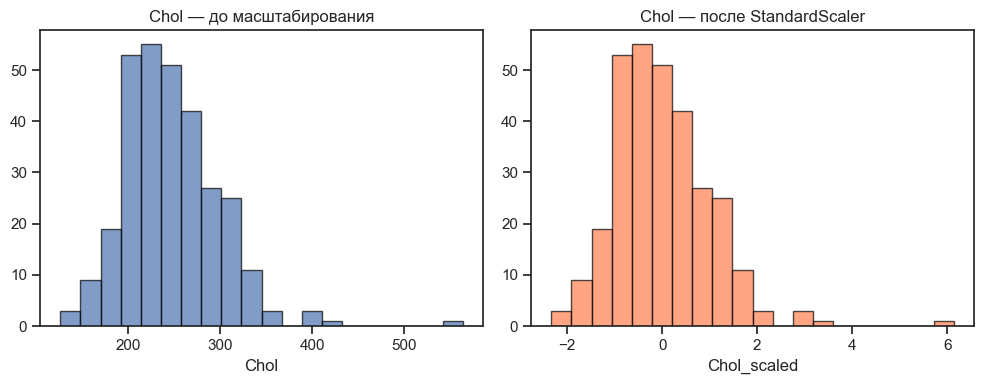

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df_enc['Chol'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Chol — до масштабирования')
axes[0].set_xlabel('Chol')

axes[1].hist(df_enc['Chol_scaled'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Chol — после StandardScaler')
axes[1].set_xlabel('Chol_scaled')
plt.tight_layout()
plt.show()


## 6. Парные диаграммы (pair plot)

Для визуализации связей между признаками строим `sns.pairplot`. Полный набор из 14 столбцов перегружает график, поэтому берём подмножество: числовые признаки + целевая `AHD`.


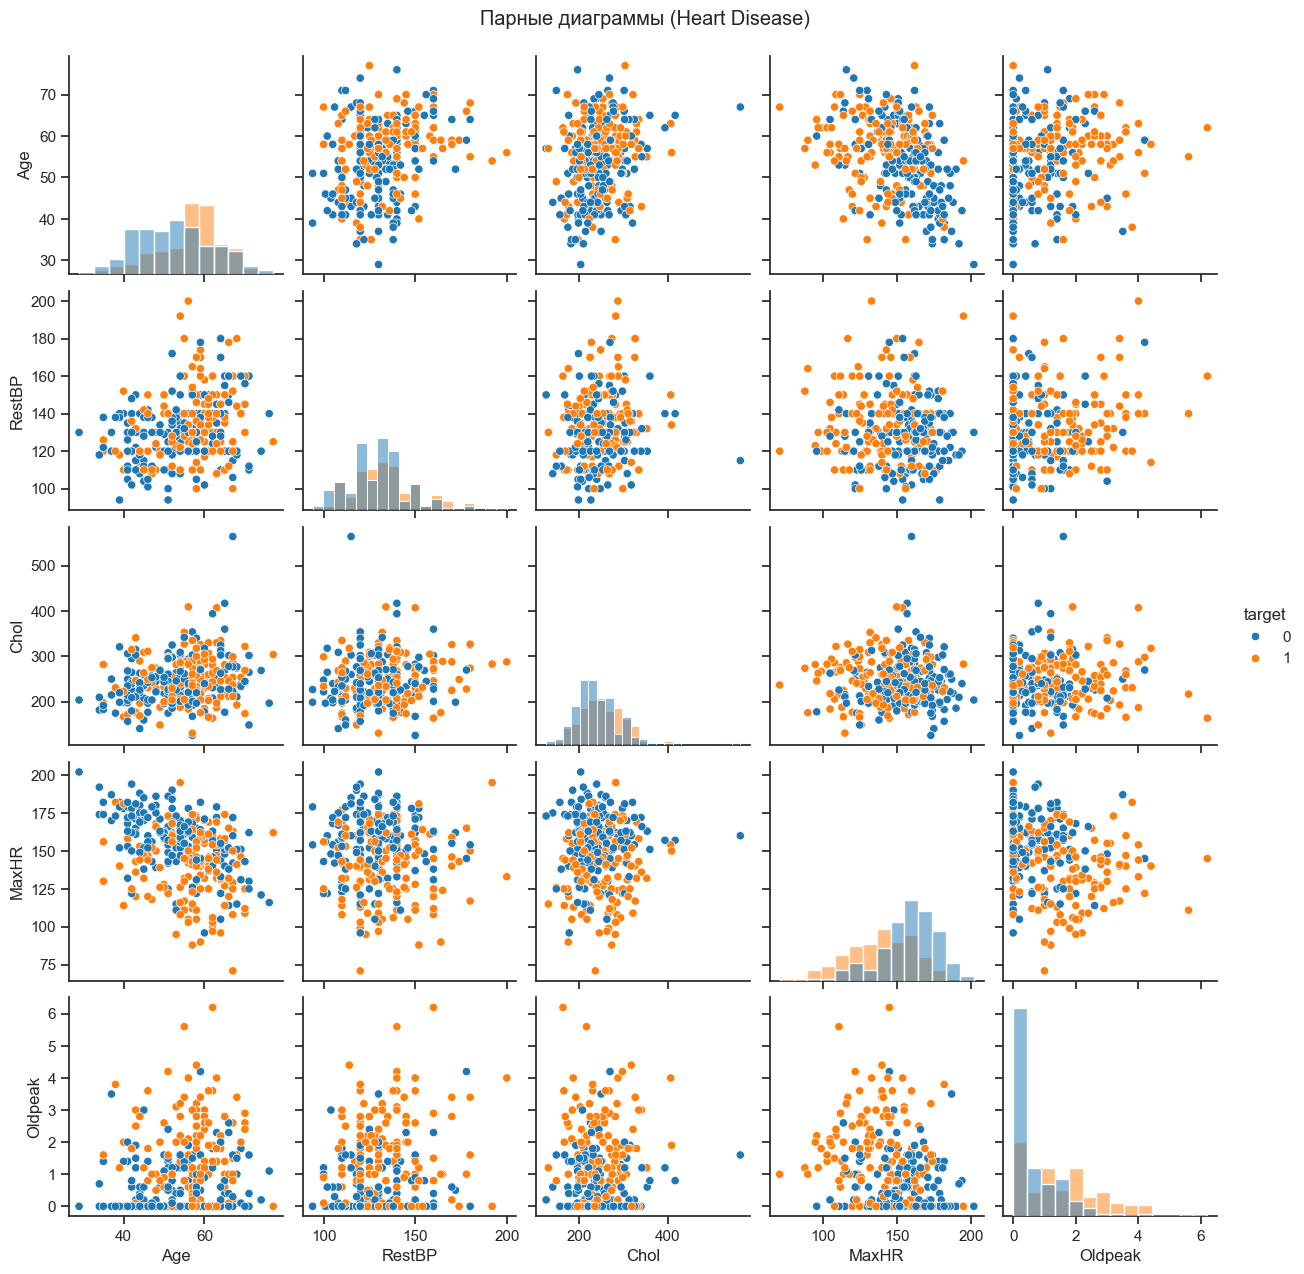

In [ ]:
# Целевая переменная для раскраски
df_plot = df_enc.copy()
df_plot['target'] = (df_plot['AHD'] == 'Yes').astype(int)

pair_cols = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'target']
sns.pairplot(df_plot[pair_cols], hue='target', palette='tab10', diag_kind='hist')
plt.suptitle('Парные диаграммы (Heart Disease)', y=1.02)
plt.show()


## 7. Выводы

| Задача | Метод | Признак | Обоснование |
|--------|--------|---------|-------------|
| Масштабирование | `StandardScaler` | `Chol` | Один числовой признак с заметным разбросом; приведение к нулевому среднему и единичной дисперсии |
| Категории → числа (способ 1) | `LabelEncoder` | `Thal` | Компактное кодирование; демонстрация метода (осторожно с номинальными данными) |
| Категории → числа (способ 2) | One-Hot | `ChestPain` | Номинальный признак без порядка; отдельный бинарный столбец на категорию |
| Визуализация | `sns.pairplot` | подмножество числовых + `target` | Оценка корреляций и разделимости классов |

**Использованные библиотеки:** `pandas`, `numpy`, `seaborn`, `matplotlib`, `sklearn` (импутация, кодирование, масштабирование).
